In [1]:
import os
import re
import shutil
import random
from collections import defaultdict, Counter

random.seed(42)

MERGED_DIR = "../dataset_merged"
CLASS_MAP = {
    "fear": "fear",
    "neutrality": "neutral",
    "sadness": "sad",
    "anger": "frustrated",
}

In [2]:
def get_sequence_prefix(filename):
    m = re.match(r"^(S\d+_\d+)_\d+\.png$", filename, re.IGNORECASE)
    return m.group(1) if m else None

for src_class in CLASS_MAP.keys():
    folder = os.path.join(MERGED_DIR, src_class)
    files = os.listdir(folder)
    groups = defaultdict(list)
    ungrouped = 0
    for f in files:
        prefix = get_sequence_prefix(f)
        if prefix:
            groups[prefix].append(f)
        else:
            ungrouped += 1
    print(f"{src_class}: {len(files)} files, {len(groups)} sequence-groups, {ungrouped} standalone files")
    if groups:
        sizes = Counter(len(v) for v in groups.values())
        print(f"  group sizes: {dict(sizes)}")

fear: 3454 files, 25 sequence-groups, 3379 standalone files
  group sizes: {3: 25}
neutrality: 5072 files, 0 sequence-groups, 5072 standalone files
sadness: 5403 files, 28 sequence-groups, 5319 standalone files
  group sizes: {3: 28}
anger: 4725 files, 45 sequence-groups, 4590 standalone files
  group sizes: {3: 45}


In [3]:
def build_split(src_class, target_class, train_ratio=0.8):
    folder = os.path.join(MERGED_DIR, src_class)
    files = os.listdir(folder)

    groups = defaultdict(list)
    standalone = []
    for f in files:
        prefix = get_sequence_prefix(f)
        (groups[prefix] if prefix else standalone).append(f)

    group_keys = list(groups.keys())
    random.shuffle(group_keys)
    n_train_groups = round(len(group_keys) * train_ratio)
    train_files = [f for k in group_keys[:n_train_groups] for f in groups[k]]
    test_files  = [f for k in group_keys[n_train_groups:] for f in groups[k]]

    random.shuffle(standalone)
    n_train_standalone = round(len(standalone) * train_ratio)
    train_files += standalone[:n_train_standalone]
    test_files  += standalone[n_train_standalone:]

    for split_name, split_files in [("train", train_files), ("test", test_files)]:
        out_dir = os.path.join(MERGED_DIR, "clean", split_name, target_class)
        os.makedirs(out_dir, exist_ok=True)
        for f in split_files:
            shutil.copy2(os.path.join(folder, f), os.path.join(out_dir, f))

    print(f"{src_class} -> {target_class}: train={len(train_files)}, test={len(test_files)}")

for src, tgt in CLASS_MAP.items():
    build_split(src, tgt)

fear -> fear: train=2763, test=691
neutrality -> neutral: train=4058, test=1014
sadness -> sad: train=4321, test=1082
anger -> frustrated: train=3780, test=945


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
IMG_SIZE = 48

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [14]:
CLEAN_TRAIN_DIR = "../dataset_merged/clean/train"
CLEAN_TEST_DIR = "../dataset_merged/clean/test"

train_dataset = datasets.ImageFolder(root=CLEAN_TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(root=CLEAN_TEST_DIR, transform=test_transform)

print("Classes:", train_dataset.classes)
print("Class to index mapping:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['fear', 'frustrated', 'neutral', 'sad']
Class to index mapping: {'fear': 0, 'frustrated': 1, 'neutral': 2, 'sad': 3}
Train samples: 14922
Test samples: 3732


In [15]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 234
Test batches: 59


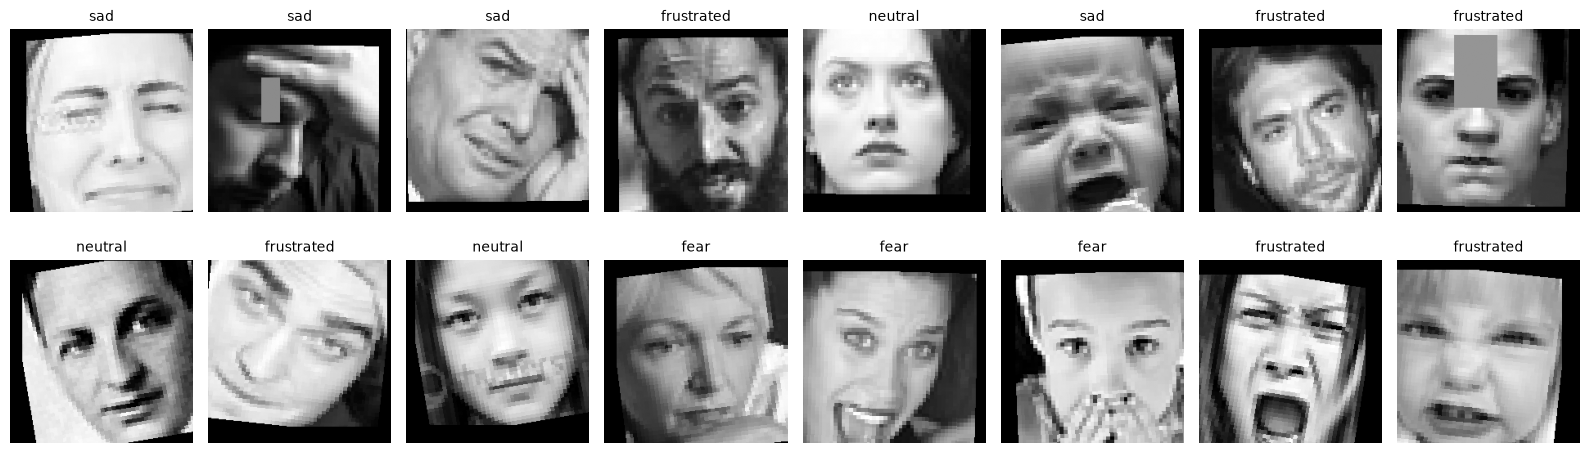

In [8]:
def imshow_batch(images, labels, classes):
    images = images.numpy()
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        img = images[i][0] * 0.5 + 0.5
        ax.imshow(img, cmap="gray")
        ax.set_title(classes[labels[i]], fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("../outputs/figures/04_sample_training_batch_merged.png", dpi=150)
    plt.show()

sample_images, sample_labels = next(iter(train_loader))
imshow_batch(sample_images, sample_labels, train_dataset.classes)

In [16]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("EmotionCNN class defined")

EmotionCNN class defined


In [17]:
model = EmotionCNN(num_classes=4).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)

Total trainable parameters: 1,274,052


In [11]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


In [18]:
NUM_EPOCHS = 45

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    checkpoint_note = ""
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../outputs/best_model_merged.pth')
        checkpoint_note = "  → New best model saved"

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {current_lr:.6f}{checkpoint_note}")

print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")

Epoch [1/45] Train Loss: 1.4398 Train Acc: 0.2483 | Val Loss: 1.4029 Val Acc: 0.2543 | LR: 0.001000  → New best model saved
Epoch [2/45] Train Loss: 1.4417 Train Acc: 0.2510 | Val Loss: 1.4030 Val Acc: 0.2559 | LR: 0.001000  → New best model saved
Epoch [3/45] Train Loss: 1.4409 Train Acc: 0.2486 | Val Loss: 1.4025 Val Acc: 0.2548 | LR: 0.001000
Epoch [4/45] Train Loss: 1.4433 Train Acc: 0.2453 | Val Loss: 1.4030 Val Acc: 0.2554 | LR: 0.001000
Epoch [5/45] Train Loss: 1.4412 Train Acc: 0.2455 | Val Loss: 1.4029 Val Acc: 0.2554 | LR: 0.001000
Epoch [6/45] Train Loss: 1.4395 Train Acc: 0.2508 | Val Loss: 1.4026 Val Acc: 0.2546 | LR: 0.001000
Epoch [7/45] Train Loss: 1.4422 Train Acc: 0.2488 | Val Loss: 1.4024 Val Acc: 0.2546 | LR: 0.000500
Epoch [8/45] Train Loss: 1.4445 Train Acc: 0.2419 | Val Loss: 1.4027 Val Acc: 0.2548 | LR: 0.000500
Epoch [9/45] Train Loss: 1.4418 Train Acc: 0.2493 | Val Loss: 1.4028 Val Acc: 0.2546 | LR: 0.000500
Epoch [10/45] Train Loss: 1.4449 Train Acc: 0.2435 |

In [19]:
batch_images, batch_labels = next(iter(train_loader))
print("Batch shape:", batch_images.shape)
print("Pixel min:", batch_images.min().item())
print("Pixel max:", batch_images.max().item())
print("Pixel mean:", batch_images.mean().item())
print("Pixel std (overall):", batch_images.std().item())

print()
for i in range(6):
    img = batch_images[i]
    lbl = train_dataset.classes[batch_labels[i]]
    print(f"Image {i}: min={img.min().item():.3f} max={img.max().item():.3f} std={img.std().item():.4f}  label={lbl}")

Batch shape: torch.Size([64, 1, 48, 48])
Pixel min: -1.0
Pixel max: 1.0
Pixel mean: -0.09428395330905914
Pixel std (overall): 0.5563277006149292

Image 0: min=-1.000 max=0.984 std=0.6366  label=sad
Image 1: min=-1.000 max=1.000 std=0.5187  label=fear
Image 2: min=-1.000 max=1.000 std=0.6454  label=fear
Image 3: min=-1.000 max=0.012 std=0.2615  label=frustrated
Image 4: min=-1.000 max=0.890 std=0.6153  label=neutral
Image 5: min=-1.000 max=0.922 std=0.7061  label=frustrated


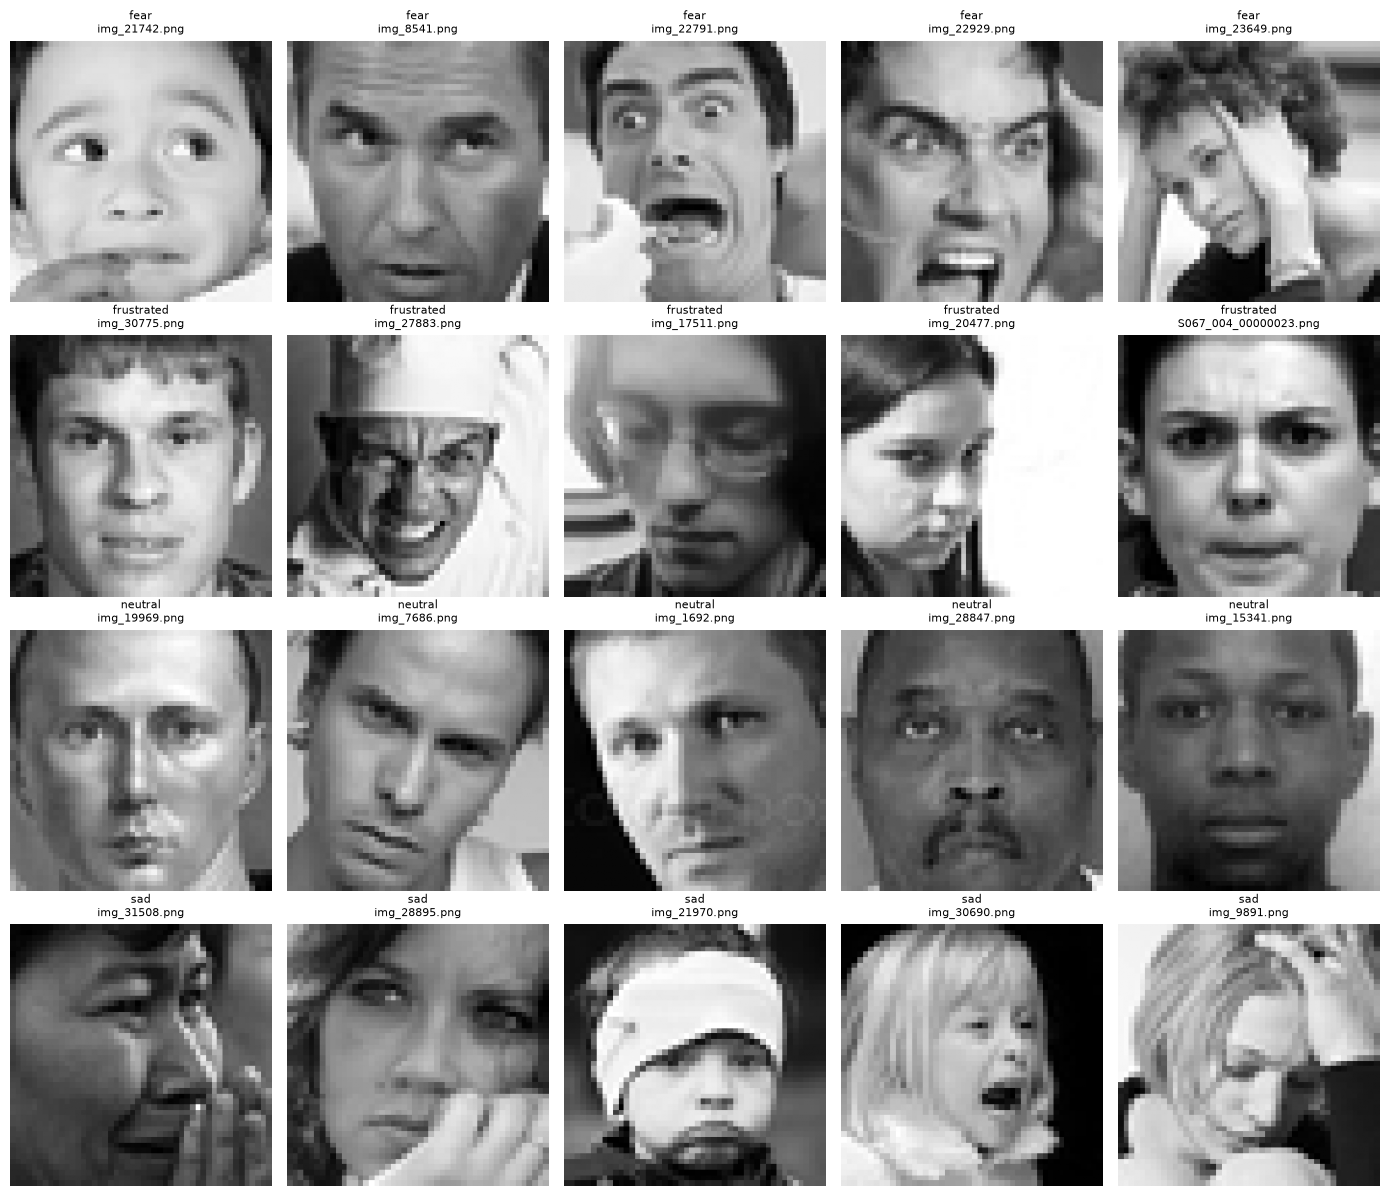

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
for row, cls in enumerate(["fear", "frustrated", "neutral", "sad"]):
    folder = f"../dataset_merged/clean/train/{cls}"
    files = random.sample(os.listdir(folder), 5)
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].set_title(f"{cls}\n{fname}", fontsize=8)
        axes[row][col].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/07_raw_class_sanity_check.png", dpi=150)
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../dataset_ferplus/fer2013plus/fer2013/train\\fear'

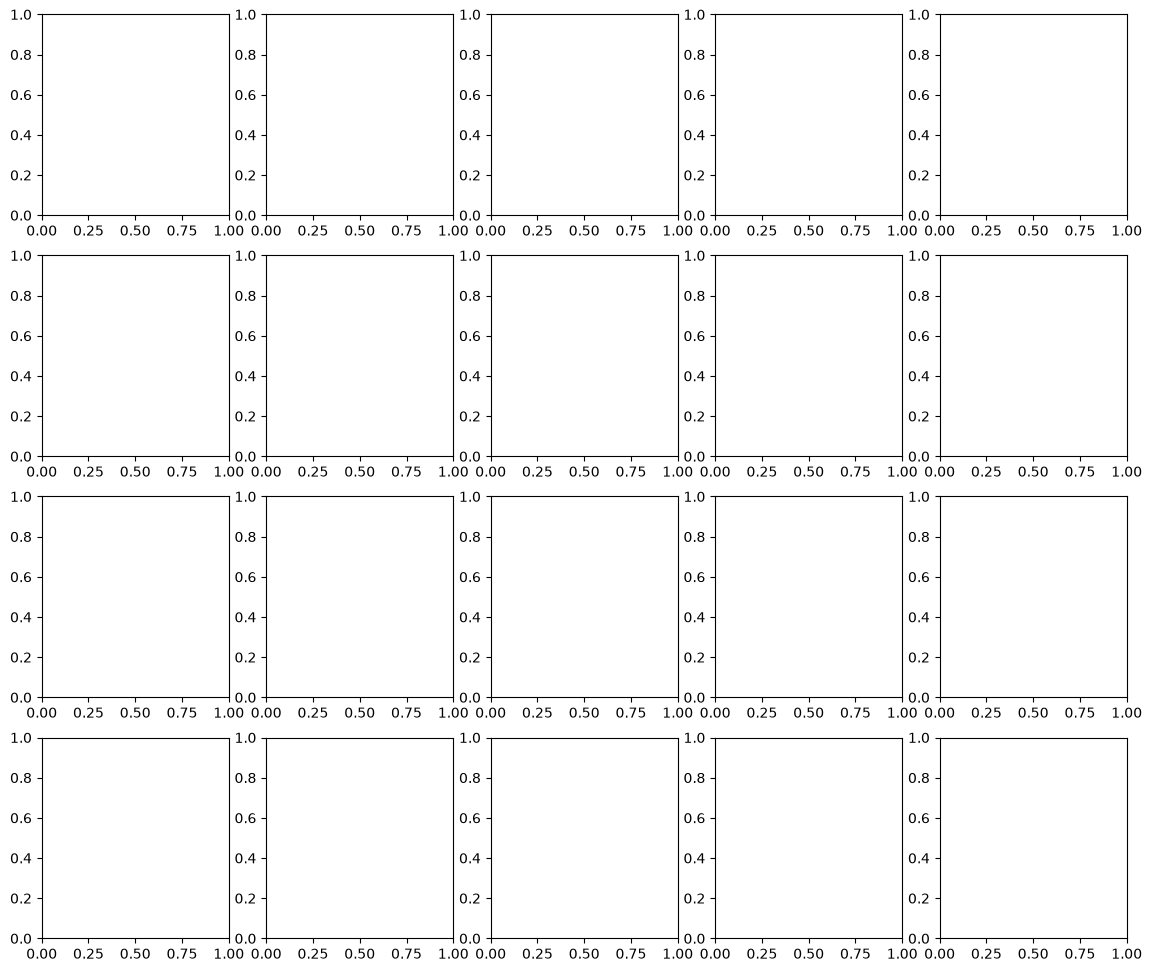

In [21]:
FERPLUS_DIR = "../dataset_ferplus/fer2013plus/fer2013/train"
CLASS_FOLDERS = {"fear": "fear", "neutrality": "neutral", "sadness": "sad", "anger": "frustrated"}

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
for row, (src, tgt) in enumerate(CLASS_FOLDERS.items()):
    folder = os.path.join(FERPLUS_DIR, src)
    files = random.sample(os.listdir(folder), 5)
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].set_title(f"{tgt}\n{fname}", fontsize=8)
        axes[row][col].axis("off")
plt.tight_layout()
plt.show()

In [22]:
import os

print("analytics-ml eke thiyena folders:")
for item in os.listdir(".."):
    print(" ", item)

print()
ferplus_path = "../dataset_ferplus"
if os.path.exists(ferplus_path):
    print(f"{ferplus_path} exists. Ethule:")
    for item in os.listdir(ferplus_path):
        print(" ", item)
else:
    print(f"{ferplus_path} — NOT FOUND")

analytics-ml eke thiyena folders:
  dataset
  dataset_merged
  fer_env
  models
  notebooks
  outputs

../dataset_ferplus — NOT FOUND


In [23]:
ferplus_path = "../dataset_ferplus"
if os.path.exists(ferplus_path):
    print(f"{ferplus_path} exists. Ethule:")
    for item in os.listdir(ferplus_path):
        print(" ", item)
else:
    print(f"{ferplus_path} — NOT FOUND")

../dataset_ferplus exists. Ethule:
  fer2013plus


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../dataset_ferplus/fer2013plus/fer2013/train\\neutrality'

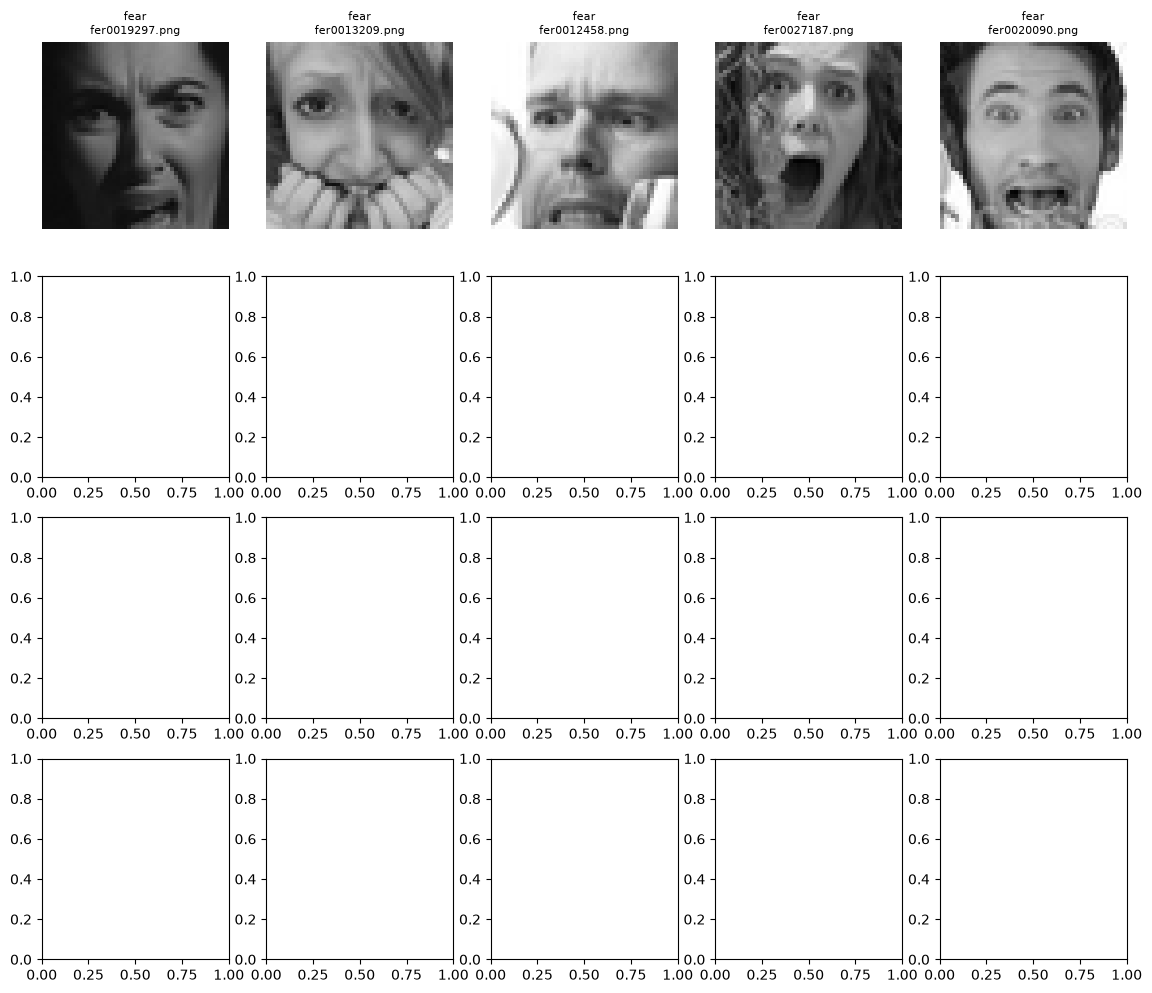

In [24]:
from PIL import Image
import random

FERPLUS_DIR = "../dataset_ferplus/fer2013plus/fer2013/train"
CLASS_FOLDERS = {"fear": "fear", "neutrality": "neutral", "sadness": "sad", "anger": "frustrated"}

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
for row, (src, tgt) in enumerate(CLASS_FOLDERS.items()):
    folder = os.path.join(FERPLUS_DIR, src)
    files = random.sample(os.listdir(folder), 5)
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].set_title(f"{tgt}\n{fname}", fontsize=8)
        axes[row][col].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/07_ferplus_sanity_check.png", dpi=150)
plt.show()

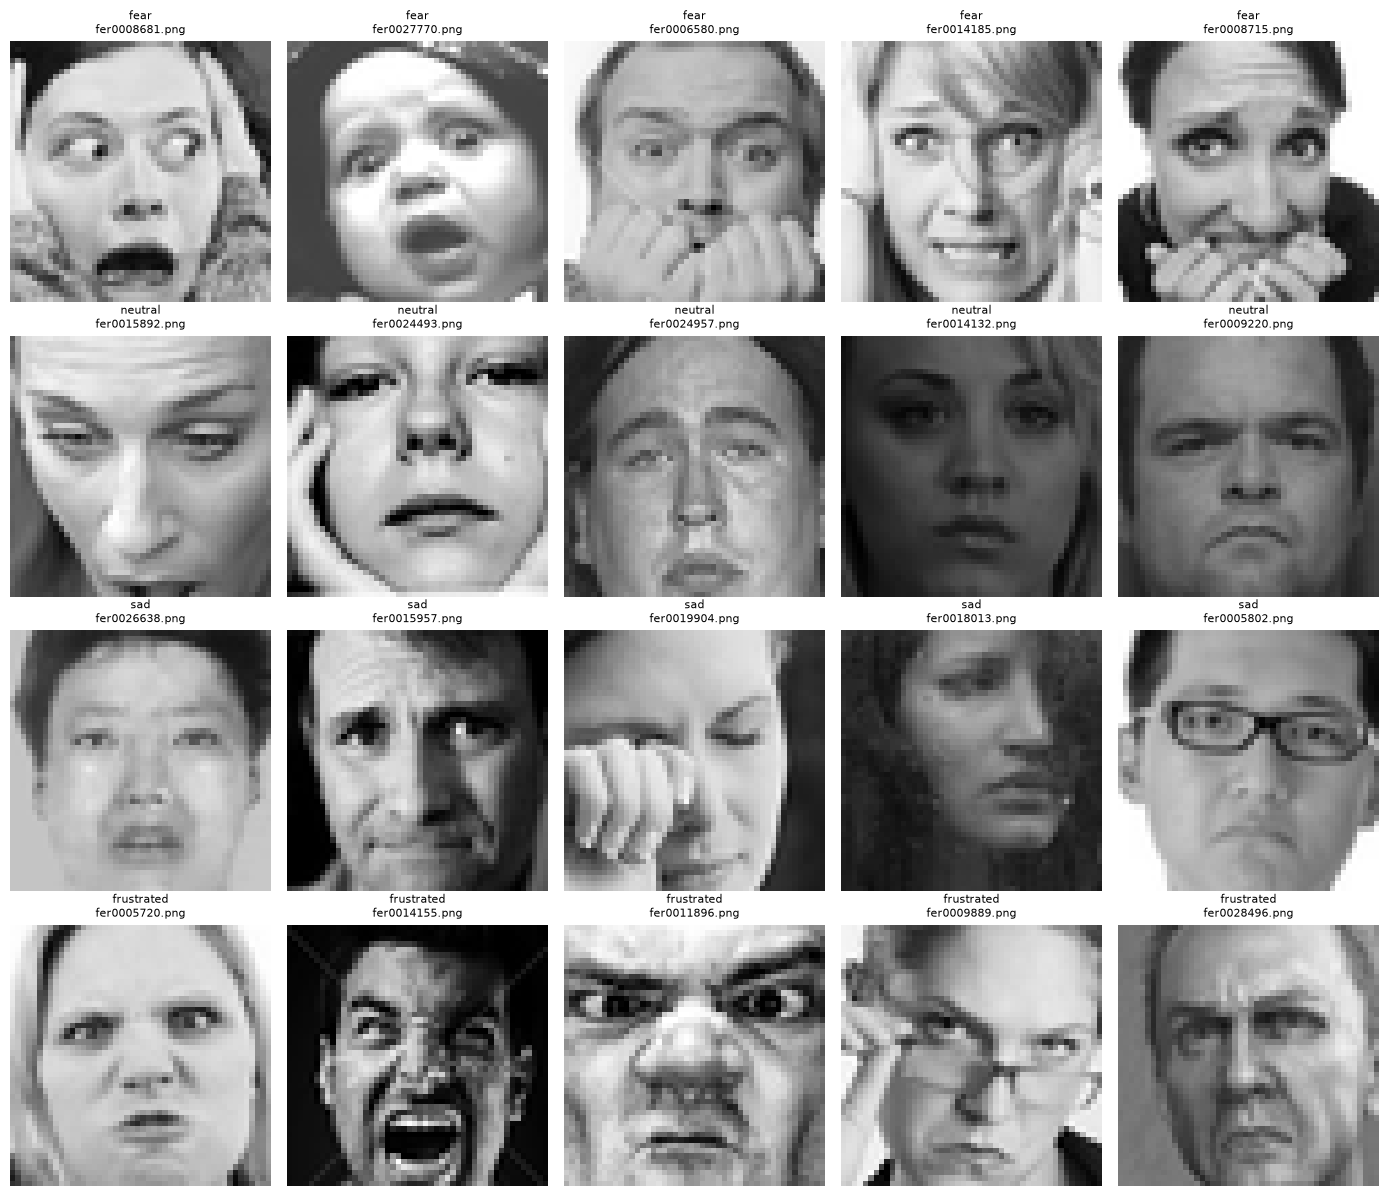

In [25]:
CLASS_FOLDERS = {"fear": "fear", "neutral": "neutral", "sadness": "sad", "anger": "frustrated"}

fig, axes = plt.subplots(4, 5, figsize=(14, 12))
for row, (src, tgt) in enumerate(CLASS_FOLDERS.items()):
    folder = os.path.join(FERPLUS_DIR, src)
    files = random.sample(os.listdir(folder), 5)
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].set_title(f"{tgt}\n{fname}", fontsize=8)
        axes[row][col].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/07_ferplus_sanity_check.png", dpi=150)
plt.show()

In [26]:
sample_img = Image.open("../dataset_ferplus/fer2013plus/fer2013/train/fear/" + os.listdir("../dataset_ferplus/fer2013plus/fer2013/train/fear")[0])
print("Image size:", sample_img.size, "Mode:", sample_img.mode)

Image size: (48, 48) Mode: RGB


In [27]:
FERPLUS_ROOT = "../dataset_ferplus/fer2013plus/fer2013"
CLASS_MAP = {"fear": "fear", "neutral": "neutral", "sadness": "sad", "anger": "frustrated"}

for split in ["train", "test"]:
    for src, tgt in CLASS_MAP.items():
        src_folder = os.path.join(FERPLUS_ROOT, split, src)
        out_folder = os.path.join("../dataset_ferplus/clean", split, tgt)
        os.makedirs(out_folder, exist_ok=True)
        files = os.listdir(src_folder)
        for f in files:
            shutil.copy2(os.path.join(src_folder, f), os.path.join(out_folder, f))
        print(f"{split}/{src} -> {tgt}: {len(files)} files")

train/fear -> fear: 652 files
train/neutral -> neutral: 10308 files
train/sadness -> sad: 3514 files
train/anger -> frustrated: 2466 files
test/fear -> fear: 167 files
test/neutral -> neutral: 2597 files
test/sadness -> sad: 856 files
test/anger -> frustrated: 644 files


In [28]:
CLEAN_TRAIN_DIR = "../dataset_ferplus/clean/train"
CLEAN_TEST_DIR = "../dataset_ferplus/clean/test"

In [29]:
CLEAN_TRAIN_DIR = "../dataset_ferplus/clean/train"
CLEAN_TEST_DIR = "../dataset_ferplus/clean/test"

train_dataset = datasets.ImageFolder(root=CLEAN_TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(root=CLEAN_TEST_DIR, transform=test_transform)

print("Classes:", train_dataset.classes)
print("Class to index mapping:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['fear', 'frustrated', 'neutral', 'sad']
Class to index mapping: {'fear': 0, 'frustrated': 1, 'neutral': 2, 'sad': 3}
Train samples: 16940
Test samples: 4264


In [30]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 265
Test batches: 67


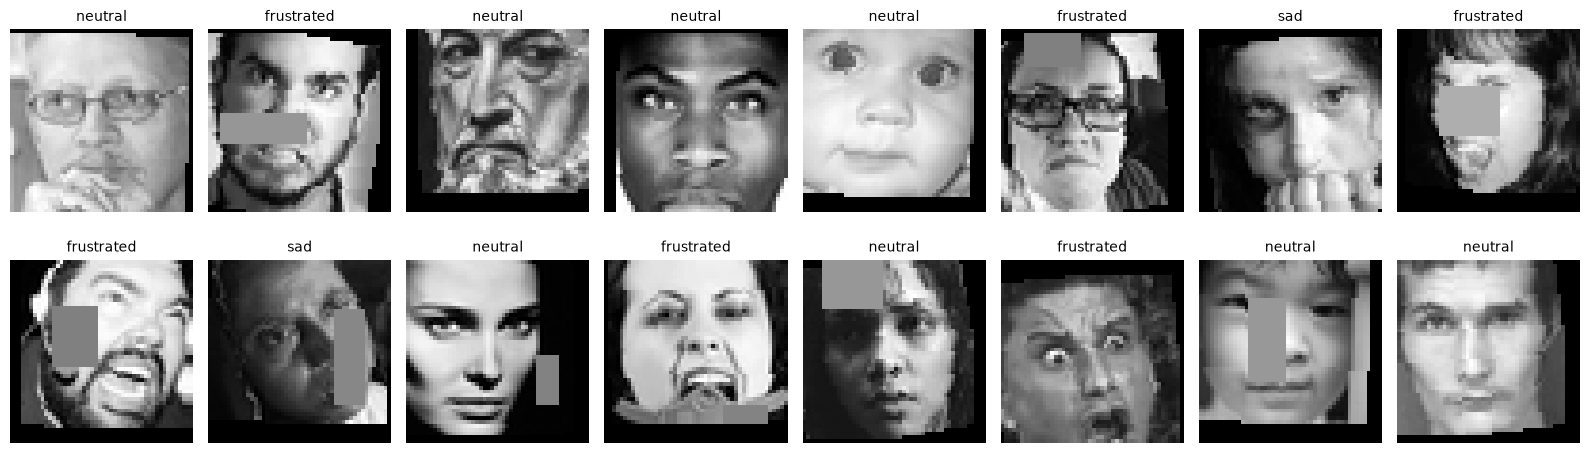

In [31]:
def imshow_batch(images, labels, classes):
    images = images.numpy()
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        img = images[i][0] * 0.5 + 0.5
        ax.imshow(img, cmap="gray")
        ax.set_title(classes[labels[i]], fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("../outputs/figures/08_ferplus_training_batch.png", dpi=150)
    plt.show()

sample_images, sample_labels = next(iter(train_loader))
imshow_batch(sample_images, sample_labels, train_dataset.classes)

In [32]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = EmotionCNN(num_classes=4).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 1,274,052


In [37]:
class_counts = {"fear": 652, "frustrated": 2466, "neutral": 10308, "sad": 3514}
total = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = torch.tensor([
    total / (num_classes * class_counts["fear"]),
    total / (num_classes * class_counts["frustrated"]),
    total / (num_classes * class_counts["neutral"]),
    total / (num_classes * class_counts["sad"]),
], dtype=torch.float32).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

Class weights: tensor([6.4954, 1.7174, 0.4108, 1.2052], device='cuda:0')


In [38]:
NUM_EPOCHS = 45
train_losses, train_accuracies, val_losses, val_accuracies = [], [], [], []
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    checkpoint_note = ""
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../outputs/best_model_ferplus_v2.pth')
        checkpoint_note = "  → New best model saved"

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {epoch_train_loss:.4f} Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}{checkpoint_note}")

print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")

Epoch [1/45] Train Loss: 1.1160 Train Acc: 0.6971 | Val Loss: 1.4818 Val Acc: 0.7364 | LR: 0.001000  → New best model saved
Epoch [2/45] Train Loss: 1.0962 Train Acc: 0.7096 | Val Loss: 1.4574 Val Acc: 0.7671 | LR: 0.001000  → New best model saved
Epoch [3/45] Train Loss: 1.0977 Train Acc: 0.7122 | Val Loss: 1.5601 Val Acc: 0.6628 | LR: 0.001000
Epoch [4/45] Train Loss: 1.0826 Train Acc: 0.7192 | Val Loss: 1.4663 Val Acc: 0.7533 | LR: 0.001000
Epoch [5/45] Train Loss: 1.0835 Train Acc: 0.7173 | Val Loss: 1.5288 Val Acc: 0.7268 | LR: 0.001000
Epoch [6/45] Train Loss: 1.0690 Train Acc: 0.7191 | Val Loss: 1.5316 Val Acc: 0.7249 | LR: 0.000500
Epoch [7/45] Train Loss: 1.0429 Train Acc: 0.7409 | Val Loss: 1.4871 Val Acc: 0.7535 | LR: 0.000500
Epoch [8/45] Train Loss: 1.0395 Train Acc: 0.7483 | Val Loss: 1.5021 Val Acc: 0.7418 | LR: 0.000500
Epoch [9/45] Train Loss: 1.0352 Train Acc: 0.7534 | Val Loss: 1.5298 Val Acc: 0.7099 | LR: 0.000500
Epoch [10/45] Train Loss: 1.0350 Train Acc: 0.7509 |

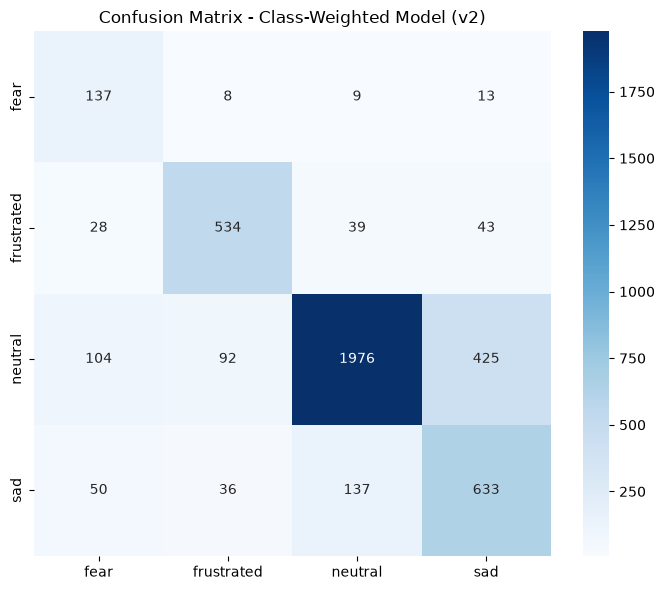

              precision    recall  f1-score   support

        fear       0.43      0.82      0.56       167
  frustrated       0.80      0.83      0.81       644
     neutral       0.91      0.76      0.83      2597
         sad       0.57      0.74      0.64       856

    accuracy                           0.77      4264
   macro avg       0.68      0.79      0.71      4264
weighted avg       0.81      0.77      0.78      4264



In [39]:
eval_model = EmotionCNN(num_classes=4).to(device)
eval_model.load_state_dict(torch.load('../outputs/best_model_ferplus_v2.pth', map_location=device))
eval_model.eval()

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = eval_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = train_dataset.classes
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Class-Weighted Model (v2)')
plt.tight_layout()
plt.savefig('../outputs/figures/10_confusion_matrix_ferplus_v2.png', dpi=150)
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [40]:
eval_model = EmotionCNN(num_classes=4).to(device)
eval_model.load_state_dict(torch.load('../outputs/best_model_ferplus_v2.pth', map_location=device))
eval_model.eval()

dummy_input = torch.randn(1, 1, 48, 48, device=device)
torch.onnx.export(
    eval_model, dummy_input, "../outputs/emotion_cnn_v2.onnx",
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)

import onnxruntime as ort
ort_session = ort.InferenceSession("../outputs/emotion_cnn_v2.onnx")
sample_image = dummy_input.cpu().numpy()
pytorch_output = eval_model(dummy_input).detach().cpu().numpy()
onnx_output = ort_session.run(None, {'input': sample_image})[0]
print("Max diff:", np.max(np.abs(pytorch_output - onnx_output)))
print("Same predicted class:", np.argmax(pytorch_output, axis=1) == np.argmax(onnx_output, axis=1))

Max diff: 0.00049722195
Same predicted class: [ True]
